# 👨‍💻 PROJETO: PIPELINE DE DETEÇÃO DE ANOMALIAS E FRAUDES FINANCEIRAS

In [1]:
# Importando bibliotecas necessárias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, fbeta_score, precision_recall_curve

# Modelos e Amostragem Avançada
from imblearn.combine import SMOTETomek
from sklearn.ensemble import IsolationForest
import xgboost as xgb

In [2]:
# Configuração de estilo dos gráficos
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
sns.set_theme(style="whitegrid")

### Carregamento, Auditoria e Limpeza dos Dados

In [3]:
# Carregando os dados do nosso dataset
url = "https://raw.githubusercontent.com/nnaemeka-git/payment/main/CreditCard.csv"

df = pd.read_csv(url)

print(f"Dimensões originais do Dataset: {df.shape}\n")
print(df.head())

Dimensões originais do Dataset: (1319, 13)

   Unnamed: 0 card  reports       age  income     share  expenditure owner  \
0           1  yes        0  37.66667  4.5200  0.033270   124.983300   yes   
1           2  yes        0  33.25000  2.4200  0.005217     9.854167    no   
2           3  yes        0  33.66667  4.5000  0.004156    15.000000   yes   
3           4  yes        0  30.50000  2.5400  0.065214   137.869200    no   
4           5  yes        0  32.16667  9.7867  0.067051   546.503300   yes   

  selfemp  dependents  months  majorcards  active  
0      no           3      54           1      12  
1      no           3      34           1      13  
2      no           4      58           1       5  
3      no           0      25           1       7  
4      no           2      64           1       5  


#### Remoção de identificadores irrelevantes
- No dataset possui uma coluna chamada `Unnamed: 0` que funciona como um índice antigo. Vamos removê-la.

In [4]:
if 'Unnamed: 0' in df.columns:
    df = df.drop(columns=['Unnamed: 0'])

#### Mapeamento do Target
- 1 = Anomalia/Fraude
- 0 = Legítimo/Não é fraude

In [5]:
# Verificando a quantidade de fraudes no dataset original
print(df['card'].value_counts())

card
yes    1023
no      296
Name: count, dtype: int64


→ No contexto deste dataset, ***no*** indica transações que não foram aceitas/comportamento de risco

- Vamos criar uma coluna chamada *target* baseado na coluna *card* mas mudando os valores para facilitar o treinamento:
  - yes → 0
  - no → 1

In [6]:
df['target'] = df['card'].map({'yes': 0, 'no': 1})
df = df.drop(columns=['card']) # Excluindo a coluna card

- Tratando as colunas categóricas restantes através de **One-Hot Encoding**.

In [7]:
df = pd.get_dummies(df, drop_first=True)

### GRÁFICO 1: Visualização do Desbalanceamento

Text(0, 0.5, 'Número de Transações')

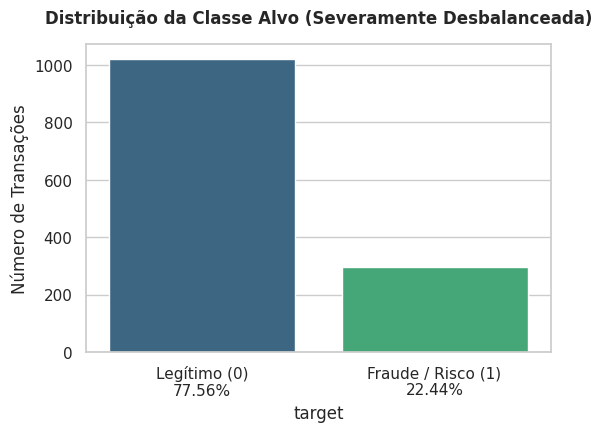

In [8]:
plt.figure(figsize=(6, 4))
contagem = df['target'].value_counts()
percentagens = df['target'].value_counts(normalize=True) * 100

ax = sns.barplot(x=contagem.index, y=contagem.values, hue=contagem.index, palette='viridis', legend=False)
plt.title('Distribuição da Classe Alvo (Severamente Desbalanceada)', fontsize=12, fontweight='bold', pad=15)
plt.xticks([0, 1], [f'Legítimo (0)\n{percentagens[0]:.2f}%', f'Fraude / Risco (1)\n{percentagens[1]:.2f}%'])
plt.ylabel('Número de Transações')

### Divisão dos Dados e Pré-processamento (Escalonamento)

In [9]:
# Separar Features (X) e Target (y)
X = df.drop(columns=['target'])
y = df['target']

→ Divisão de Treino e Teste
- Isso garante a consistência antes de qualquer balanceamento.
- Então com isso, vamos fazer a divisão estratificada para manter a proporção da fraude em ambos os lados

In [10]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

→ Escalonamento das variáveis numéricas
- Crucial para algoritmos baseados em distância/anomalias

In [11]:
# Escalonamento - Essencial para algoritmos de anomalia baseados em distância
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"\nDados de Treino: {X_train_scaled.shape} | Dados de Teste: {X_test_scaled.shape}")


Dados de Treino: (989, 11) | Dados de Teste: (330, 11)


### Engenharia de Amostragem

In [12]:
print("\n=== APLICANDO ENGENHARIA DE AMOSTRAGEM (SMOTETomek) ===")
smt = SMOTETomek(random_state=42)
X_train_res, y_train_res = smt.fit_resample(X_train_scaled, y_train)


=== APLICANDO ENGENHARIA DE AMOSTRAGEM (SMOTETomek) ===


→ Vamos utilizar a biblioteca ***NumPy*** para validar e exibir os arrays resultantes.

In [13]:
classes, counts = np.unique(y_train_res, return_counts=True)
print(f"Nova proporção de treino pós-balanceamento: {dict(zip(classes, counts))}\n")

Nova proporção de treino pós-balanceamento: {np.int64(0): np.int64(767), np.int64(1): np.int64(767)}



### Treino dos Modelos e Otimização de Threshold

#### Abordagem A: Isolation Forest (Não-Supervisionado)

→ Contaminação baseada na taxa real calculada via NumPy

In [14]:
taxa_contaminacao = np.sum(y_train == 1) / len(y_train)

if_model = IsolationForest(contamination=taxa_contaminacao, random_state=42)
if_model.fit(X_train_scaled)

IsolationForest(contamination=np.float64(0.224469160768453), random_state=42)

→ Previsões do IF (Mapeamento: -1 para anomalia, 1 para normal)

In [15]:
y_pred_if_raw = if_model.predict(X_test_scaled)
y_pred_if = np.where(y_pred_if_raw == -1, 1, 0)

#### Abordagem B: XGBoost Classifier (Supervisionado)

In [16]:
xgb_model = xgb.XGBClassifier(random_state=42, eval_metric='logloss')
xgb_model.fit(X_train_res, y_train_res)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, ...)

#### Otimização do Limiar de Decisão (Threshold)

→ Em vez de usar 0.5, reduzimos para 0.35 para priorizar o Recall de fraudes

In [17]:
y_prob_xgb = xgb_model.predict_proba(X_test_scaled)[:, 1]
threshold_otimizado = 0.35
y_pred_xgb = np.where(y_prob_xgb >= threshold_otimizado, 1, 0)

### Dashboard Executivo de Avaliação (MatplotLib & Seaborn)

In [18]:
def gerar_dashboard_executivo(y_real, pred_if, pred_xgb, prob_xgb):
    # Criar uma figura com uma matriz de subplots (Dashboard 2x2)
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    fig.suptitle('Dashboard de Performance: Detecção de Fraudes & Anomalias', fontsize=16, fontweight='bold', y=0.96)

    # 1. Matriz de Confusão - Isolation Forest
    cm_if = confusion_matrix(y_real, pred_if)
    sns.heatmap(cm_if, annot=True, fmt='d', cmap='Reds', ax=axes[0, 0], cbar=False,
                xticklabels=['Legítimo', 'Fraude'], yticklabels=['Legítimo', 'Fraude'])
    axes[0, 0].set_title('Matriz de Confusão: Isolation Forest', fontsize=12, fontweight='bold')
    axes[0, 0].set_ylabel('Realidade')
    axes[0, 0].set_xlabel('Previsão')

    # 2. Matriz de Confusão - XGBoost Otimizado
    cm_xgb = confusion_matrix(y_real, pred_xgb)
    sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Blues', ax=axes[0, 1], cbar=False,
                xticklabels=['Legítimo', 'Fraude'], yticklabels=['Legítimo', 'Fraude'])
    axes[0, 1].set_title(f'Matriz de Confusão: XGBoost (Threshold {threshold_otimizado})', fontsize=12, fontweight='bold')
    axes[0, 1].set_ylabel('Realidade')
    axes[0, 1].set_xlabel('Previsão')

    # 3. Gráfico de Comparação de Métricas de Negócio (F2-Score vs Recall)
    f2_if = fbeta_score(y_real, pred_if, beta=2)
    f2_xgb = fbeta_score(y_real, pred_xgb, beta=2)

    modelos = ['Isolation Forest', 'XGBoost + SMOTETomek']
    valores_f2 = [f2_if, f2_xgb]

    sns.barplot(x=modelos, y=valores_f2, palette='Set2', ax=axes[1, 0], hue=modelos, legend=False)
    axes[1, 0].set_title('Comparação da Métrica de Sucesso (F2-Score)', fontsize=12, fontweight='bold')
    axes[1, 0].set_ylim(0, 1.0)
    for idx, val in enumerate(valores_f2):
        axes[1, 0].text(idx, val + 0.02, f"{val:.4f}", ha='center', fontweight='bold')

    # 4. Curva Precision-Recall para o Modelo Preditivo
    precisions, recalls, _ = precision_recall_curve(y_real, prob_xgb)
    axes[1, 1].plot(recalls, precisions, color='darkorange', lw=2, label='Curva PR (XGBoost)')
    axes[1, 1].set_title('Curva Precision-Recall (Foco em Classes Desbalanceadas)', fontsize=12, fontweight='bold')
    axes[1, 1].set_xlabel('Recall (Capacidade de Capturar Fraudes)')
    axes[1, 1].set_ylabel('Precision (Evitar Alertas Falsos)')
    axes[1, 1].legend(loc="lower left")

    plt.tight_layout(rect=[0, 0.03, 1, 0.93])
    plt.show()

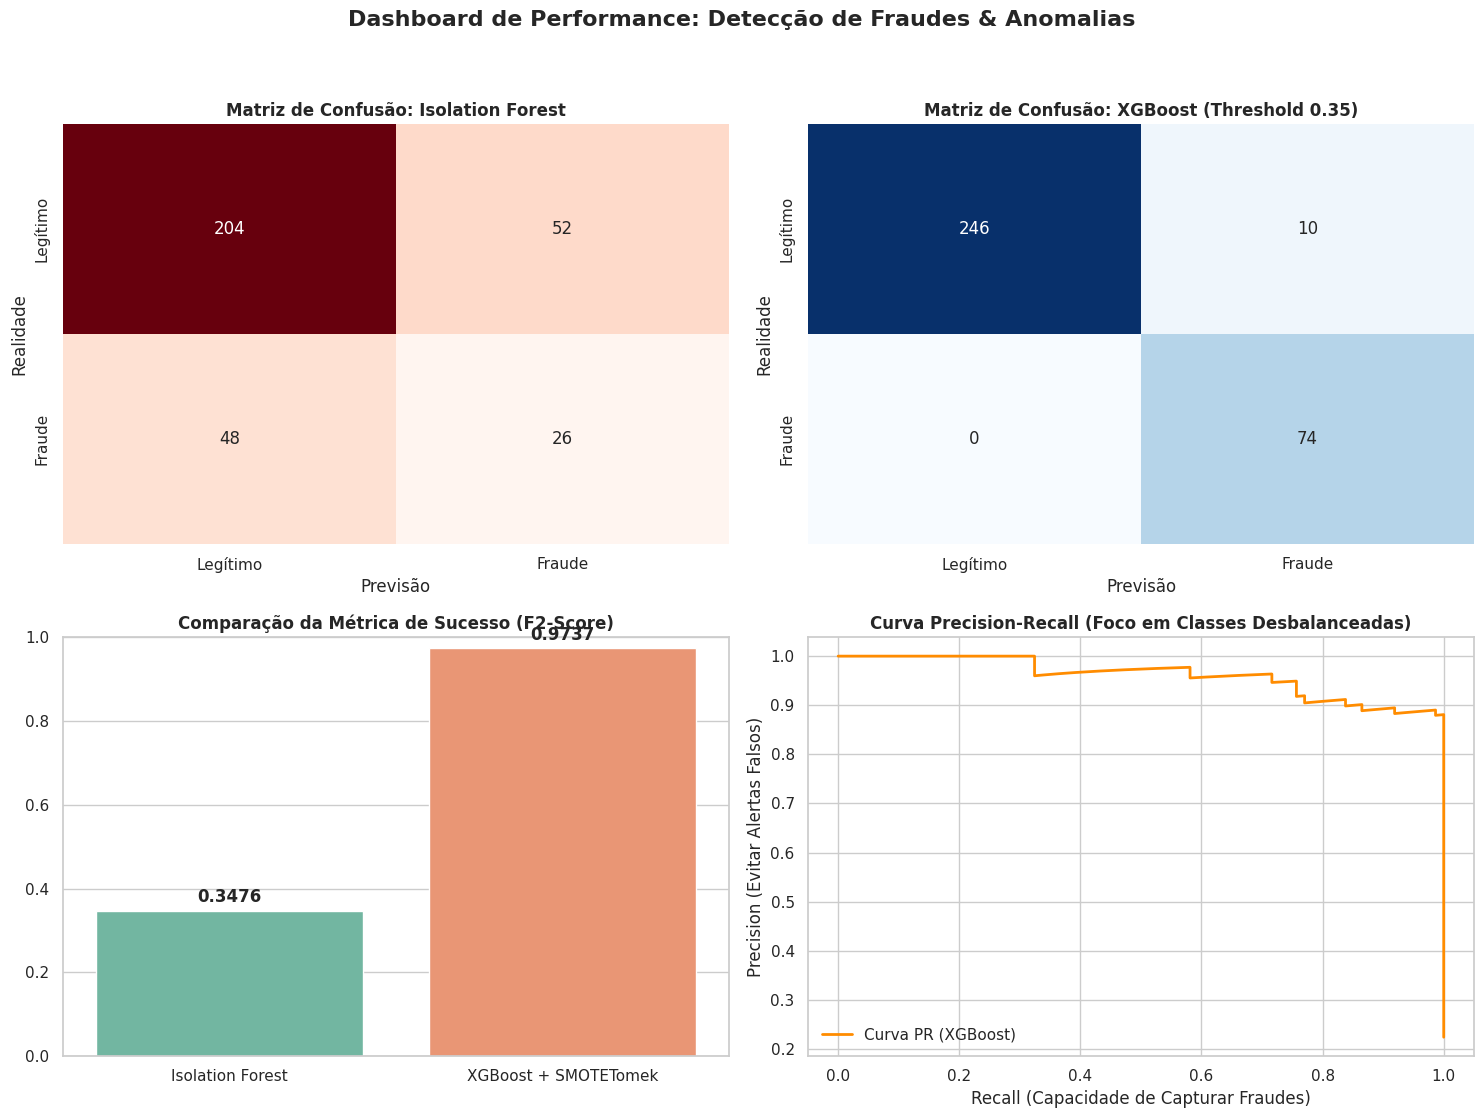

In [19]:
gerar_dashboard_executivo(y_test, y_pred_if, y_pred_xgb, y_prob_xgb)

In [20]:
# Exibir os relatórios textuais finais para auditoria detalhada
print("\n=== RELATÓRIO FINAL: ISOLATION FOREST ===")
print(classification_report(y_test, y_pred_if))

print("\n=== RELATÓRIO FINAL: XGBOOST OTIMIZADO ===")
print(classification_report(y_test, y_pred_xgb))


=== RELATÓRIO FINAL: ISOLATION FOREST ===
              precision    recall  f1-score   support

           0       0.81      0.80      0.80       256
           1       0.33      0.35      0.34        74

    accuracy                           0.70       330
   macro avg       0.57      0.57      0.57       330
weighted avg       0.70      0.70      0.70       330


=== RELATÓRIO FINAL: XGBOOST OTIMIZADO ===
              precision    recall  f1-score   support

           0       1.00      0.96      0.98       256
           1       0.88      1.00      0.94        74

    accuracy                           0.97       330
   macro avg       0.94      0.98      0.96       330
weighted avg       0.97      0.97      0.97       330

